C:\Users\sheer\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
Accuracy: 0.9

Confusion Matrix:
 [[10  0  0]
 [ 1  8  0]
 [ 2  0  9]]

Classification Report:
               precision    recall  f1-score   support

           0       0.77      1.00      0.87        10
           1       1.00      0.89      0.94         9
           2       1.00      0.82      0.90        11

    accuracy                           0.90        30
   macro avg       0.92      0.90      0.90        30
weighted avg       0.92      0.90      0.90        30



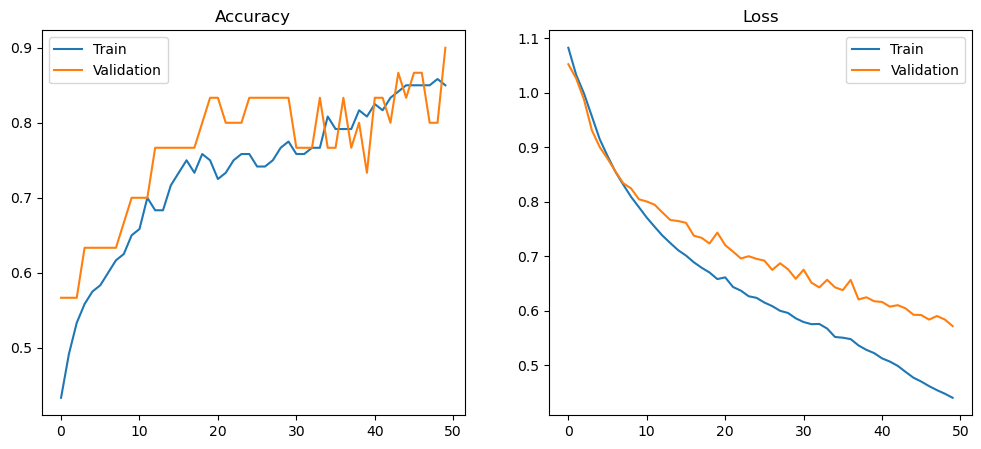

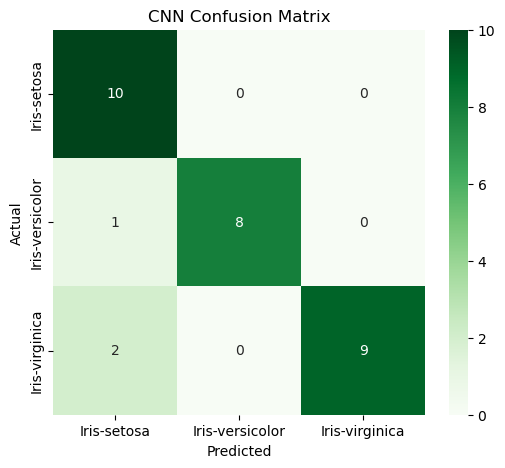

In [1]:
# ================================
# STEP 1: Import Libraries
# ================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, Flatten, Dense

# ================================
# STEP 2: Load Dataset
# ================================
columns = ["sl", "sw", "pl", "pw", "sp"]

data = pd.read_csv(
    "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data",
    header=None,
    names=columns
)

data = data.dropna()

# ================================
# STEP 3: Encode Labels
# ================================
encoder = LabelEncoder()
y = to_categorical(encoder.fit_transform(data["sp"]))

X = data.drop("sp", axis=1).values

# ================================
# STEP 4: Train-Test Split
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ================================
# STEP 5: Scaling
# ================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ================================
# STEP 6: Reshaping (for CNN)
# ================================
X_train = X_train.reshape(X_train.shape[0], 4, 1)
X_test = X_test.reshape(X_test.shape[0], 4, 1)

# ================================
# STEP 7: Build CNN Model
# ================================
model = Sequential()

model.add(Conv1D(32, kernel_size=2, activation='relu', input_shape=(4,1)))
model.add(MaxPooling1D(pool_size=2))
model.add(Flatten())
model.add(Dense(16, activation='relu'))
model.add(Dense(3, activation='softmax'))

# ================================
# STEP 8: Compile Model
# ================================
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ================================
# STEP 9: Train Model
# ================================
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=5,
    validation_data=(X_test, y_test),
    verbose=0
)

# ================================
# STEP 10: Prediction
# ================================
y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

# ================================
# STEP 11: Evaluation
# ================================
print("Accuracy:", accuracy_score(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)

print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_true, y_pred))

# ================================
# STEP 12: Plot Accuracy & Loss
# ================================
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Loss")
plt.legend()

plt.show()

# ================================
# STEP 13: Confusion Matrix Plot
# ================================
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Confusion Matrix")
plt.show()